<a href="https://colab.research.google.com/github/Saurav-K-yadav/ml_learning/blob/main/Pytorch/pytorch_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Neural network classification with pytorch


In [3]:
import numpy as np
import sklearn
from sklearn.datasets import make_circles

In [4]:
import pandas as pd


In [5]:
n_samples=1000
X,y=make_circles(n_samples,noise=0.03,random_state=42)
X=pd.DataFrame(X)
y=pd.DataFrame(y)

In [6]:
print(f"{X[:5]} \n")
print(y[:5])
y[y==[0]].value_counts()
y[y==[1]].value_counts()

          0         1
0  0.754246  0.231481
1 -0.756159  0.153259
2 -0.815392  0.173282
3 -0.393731  0.692883
4  0.442208 -0.896723 

   0
0  1
1  1
2  1
3  1
4  0


,count
0,
1.0,500


In [7]:
# making a single dataframe
circles=pd.DataFrame({
   "X1":X.iloc[:,0],
   "X2":X.iloc[:,1],
   "label":y.squeeze()
})

In [8]:
circles.head()

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


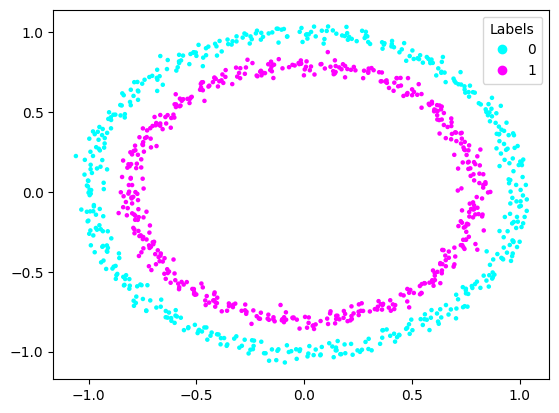

In [9]:
import matplotlib.pyplot as plt
scatter=plt.scatter(x=circles['X1'],y=circles['X2'],c=circles['label'],cmap=plt.cm.cool,s=5)
plt.legend(*scatter.legend_elements(), title="Labels")
plt.show()

checking input and output shapes

In [10]:
X.shape,y.shape

((1000, 2), (1000, 1))

Turning the data into tensors to work with


In [11]:
import torch


In [12]:
X=torch.from_numpy(X.values).type(torch.float)
y=torch.from_numpy(y.values).type(torch.float)

In [13]:
X.dtype,y.dtype

(torch.float32, torch.float32)

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [16]:
len(X_train),len(X_test)

(800, 200)

Building a model

In [17]:
# setting up device agnostice code so GPU will be used if available
from torch import nn

device="cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

Constructing the model
1. subclass nn.Module
2. create 2 linear layers
3. define a forward method
4. instantiate an instance of model and send it to target device


In [18]:
class CircleModule(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1=nn.Linear(in_features=2,out_features=4)#takes 2 features and gives
    self.layer_2=nn.Linear(in_features=4,out_features=1)
# define a forward pass
  def forward(self,x):
    return self.layer_2(self.layer_1(x))#x->layer_1->layer2

  # instantiate a instance of model class
model_0=CircleModule().to(device)
model_0

CircleModule(
  (layer_1): Linear(in_features=2, out_features=4, bias=True)
  (layer_2): Linear(in_features=4, out_features=1, bias=True)
)

In [19]:
# alternative way to define
# model_0=nn.Sequential(
#     nn.Linear(in_features=2,out_features=4),
#     nn.Linear(in_features=4,out_features=1)
# ).to(device)


In [20]:
model_0.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[-0.5387,  0.5785],
                      [-0.5294,  0.4367],
                      [-0.1494, -0.6385],
                      [-0.1661, -0.0148]])),
             ('layer_1.bias', tensor([-0.2698, -0.1891,  0.6414,  0.3323])),
             ('layer_2.weight',
              tensor([[ 0.2039, -0.2771,  0.1124,  0.1131]])),
             ('layer_2.bias', tensor([-0.1943]))])

In [21]:
# setting up loss functions
loss_fn=nn.BCEWithLogitsLoss()
# loss_fn=nn.BCELoss()
optimizer=torch.optim.SGD(params=model_0.parameters(),lr=0.01)

In [22]:
# calculate accuracy
def accuracy_fn(y_true,y_pred):
  correct=torch.eq(y_true.squeeze(),y_pred.squeeze()).sum().item()
  acc=(correct/len(y_pred))*100
  return acc


In [23]:
# training the model
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs=100
X_train,y_train=X_train.to(device),y_train.to(device)
X_test,y_test=X_test.to(device),y_test.to(device)

for epoch in range(epochs):
  model_0.train()
  # forward pass
  y_logits=model_0(X_train).squeeze()
  y_pred=torch.round(torch.sigmoid(y_logits))
# bcelogits loss needs value without sigmoids
  loss=loss_fn(y_logits,y_train.squeeze( ))
  acc=accuracy_fn(y_train,y_pred)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  # testing
  model_0.eval()
  with torch.inference_mode():
    test_logits=model_0(X_test).squeeze()
    test_pred=torch.round(torch.sigmoid(test_logits))
    test_loss=loss_fn(test_logits,test_pred)
    test_accuracy=accuracy_fn(y_test,test_pred)
  if epoch%10==0:
    print(f"epoch {epoch} | loss {loss:.5f}, Acc:{acc:.2f}| testloss: {test_loss:.5f}| testacc: {test_accuracy:.5f}\n")






epoch 0 | loss 0.69413, Acc:50.00| testloss: 0.65126| testacc: 50.00000

epoch 10 | loss 0.69406, Acc:50.00| testloss: 0.65295| testacc: 50.00000

epoch 20 | loss 0.69399, Acc:49.50| testloss: 0.65454| testacc: 49.00000

epoch 30 | loss 0.69393, Acc:46.75| testloss: 0.65598| testacc: 44.00000

epoch 40 | loss 0.69388, Acc:45.12| testloss: 0.65718| testacc: 42.00000

epoch 50 | loss 0.69383, Acc:43.25| testloss: 0.65828| testacc: 40.50000

epoch 60 | loss 0.69378, Acc:42.25| testloss: 0.65925| testacc: 37.50000

epoch 70 | loss 0.69374, Acc:42.62| testloss: 0.66012| testacc: 38.50000

epoch 80 | loss 0.69370, Acc:44.12| testloss: 0.66088| testacc: 39.50000

epoch 90 | loss 0.69367, Acc:45.38| testloss: 0.66151| testacc: 40.50000



In [24]:
# Taken from https://github.com/mrdbourke/pytorch-deep-learning/blob/main/helper_functions.py

def plot_predictions(
    train_data, train_labels, test_data, test_labels, predictions=None
):
    """
  Plots linear training data and test data and compares predictions.
  """
    plt.figure(figsize=(10, 7))

    # Plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

    # Plot test data in green
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

    if predictions is not None:
        # Plot the predictions in red (predictions were made on the test data)
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")
    # Show the legend
    plt.legend(prop={"size": 14})



In [25]:
# Taken from https://github.com/mrdbourke/pytorch-deep-learning/blob/main/helper_functions.py

def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor):
    """Plots decision boundaries of model predicting on X in comparison to y.

    Source - https://madewithml.com/courses/foundations/neural-networks/ (with modifications)
    """
    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Setup prediction boundaries and grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)  # mutli-class
    else:
        y_pred = torch.round(torch.sigmoid(y_logits))  # binary

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

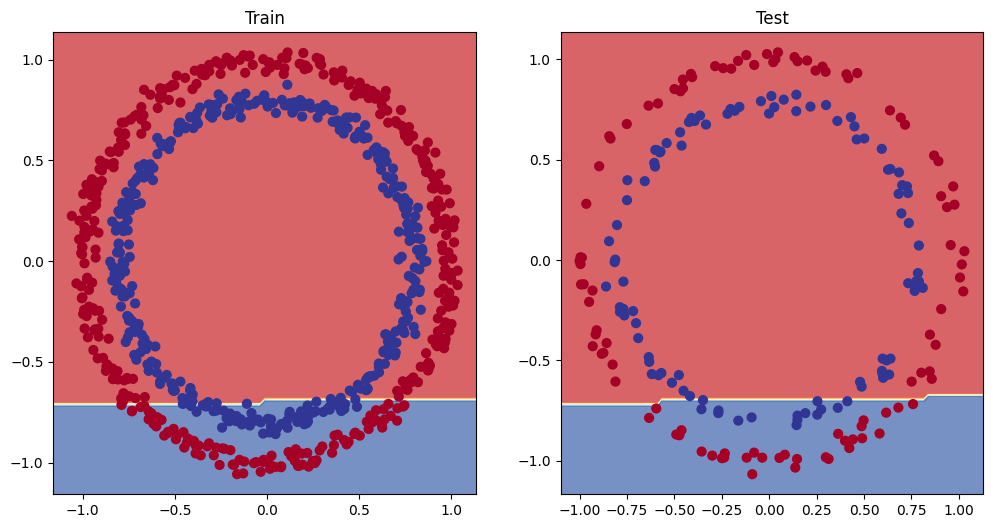

In [26]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0,X_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0,X_test,y_test)

# plot_predictions(X_train,y_train)

Improving a model
1. Add more layers
2. Add more hidden units
3. Fit for longer
4. Change the activation function
5. Changing the learning rate
6. change the loss function

7. ...

In [27]:
class CircleModuleV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1=nn.Linear(in_features=2,out_features=10)
    self.layer2=nn.Linear(in_features=10,out_features=10)
    self.relu=nn.ReLU()
    self.layer3=nn.Linear(in_features=10,out_features=1)
  def forward(self,x):
    # z=self.layer1(x)
    # z=self.relu(z)
    # z=self.layer2(z)
    # z=self.relu(z)
    # z=self.layer3(z)
    return self.layer3(self.relu(self.layer2(self.relu(self.layer1(x)))))
model_1=CircleModuleV1().to(device)
model_1


CircleModuleV1(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=10, bias=True)
  (relu): ReLU()
  (layer3): Linear(in_features=10, out_features=1, bias=True)
)

In [28]:
# create a loss function and optimizer
loss_fn1=nn.BCEWithLogitsLoss()
optimizer1=torch.optim.Adam(params=model_1.parameters(),
                           lr=0.01)

In [29]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs=10000
X_train,y_train=X_train.to(device),y_train.to(device)
X_test,y_test=X_test.to(device),y_test.to(device)
for epoch in range(epochs):
  model_1.train()
  y_logits=model_1(X_train).squeeze()
  y_pred=torch.round(torch.sigmoid(y_logits))

  loss=loss_fn1(y_logits,y_train.squeeze())
  acc=accuracy_fn(y_pred,y_train)
  optimizer1.zero_grad()
  loss.backward()
  optimizer1.step()

  model_1.eval()
  with torch.inference_mode():
    test_logits=model_1(X_test).squeeze()
    test_pred=torch.round(torch.sigmoid(test_logits))
    test_loss=loss_fn1(test_logits,y_test.squeeze())
    test_acc=accuracy_fn(y_test,test_pred)
  if epoch%100==0:
    print(f"Epoch:{epoch} | loss {loss:.5f}|accuracy {acc:.5f} | test loss {test_loss:.5f} | test accuracy {test_acc: .2f}")




Epoch:0 | loss 0.69292|accuracy 50.00000 | test loss 0.69242 | test accuracy  52.00
Epoch:100 | loss 0.18032|accuracy 99.50000 | test loss 0.16636 | test accuracy  99.50
Epoch:200 | loss 0.02056|accuracy 100.00000 | test loss 0.02526 | test accuracy  99.00
Epoch:300 | loss 0.00552|accuracy 100.00000 | test loss 0.01128 | test accuracy  99.50
Epoch:400 | loss 0.00274|accuracy 100.00000 | test loss 0.00723 | test accuracy  100.00
Epoch:500 | loss 0.00170|accuracy 100.00000 | test loss 0.00467 | test accuracy  100.00
Epoch:600 | loss 0.00119|accuracy 100.00000 | test loss 0.00380 | test accuracy  100.00
Epoch:700 | loss 0.00089|accuracy 100.00000 | test loss 0.00292 | test accuracy  100.00
Epoch:800 | loss 0.00070|accuracy 100.00000 | test loss 0.00195 | test accuracy  100.00
Epoch:900 | loss 0.00051|accuracy 100.00000 | test loss 0.00152 | test accuracy  100.00
Epoch:1000 | loss 0.00033|accuracy 100.00000 | test loss 0.00179 | test accuracy  100.00
Epoch:1100 | loss 0.00021|accuracy 100.

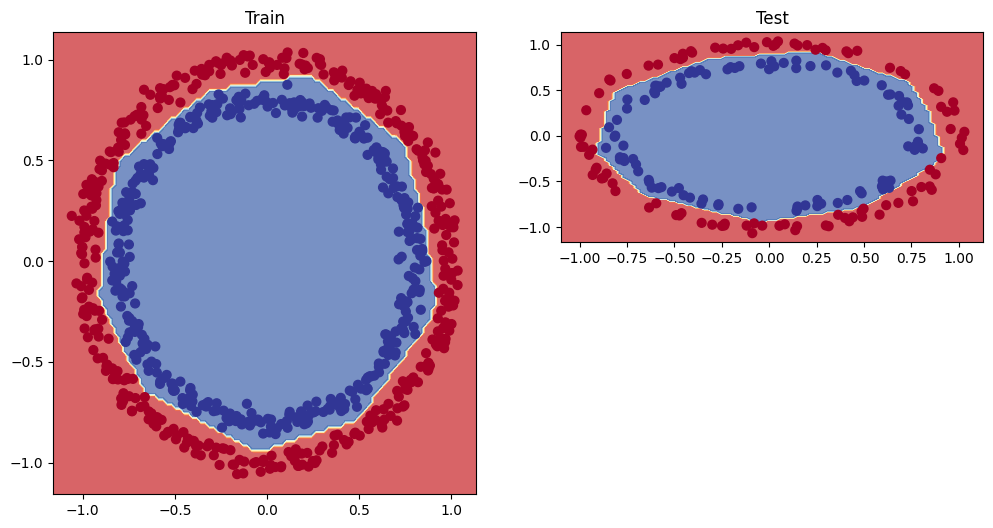

In [30]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1,X_train,y_train)
plt.subplot(2,2,2)
plt.title("Test")
plot_decision_boundary(model_1,X_test,y_test

                       )


In [31]:
model_1.state_dict()

OrderedDict([('layer1.weight',
              tensor([[ 0.0961,  1.7096],
                      [-1.8565,  1.9338],
                      [-0.1549,  0.1427],
                      [-2.6194, -1.3748],
                      [ 0.7416, -2.5658],
                      [ 0.4333,  0.0286],
                      [ 2.6889, -0.4795],
                      [ 0.3410, -0.0998],
                      [ 1.6445,  1.7109],
                      [-0.3301,  0.1802]])),
             ('layer1.bias',
              tensor([-0.5325, -1.3555, -0.2872, -1.4250, -1.1677, -0.5023, -1.7048, -0.4252,
                      -0.9400, -0.6984])),
             ('layer2.weight',
              tensor([[-1.2535e-01, -1.0741e+00,  2.4414e-01, -1.0215e+00, -1.0456e+00,
                       -1.3599e-02, -1.4694e+00,  2.5550e-01, -5.1184e-01, -9.9730e-02],
                      [ 1.3938e+00,  1.6821e+00,  1.3309e-01,  2.0967e+00,  1.9827e+00,
                        7.7285e-02,  2.1735e+00,  5.6581e-02,  1.7409e+00, -1.9274e-

### Creating one for multiclass dataset


In [32]:
from sklearn.datasets import make_blobs

In [33]:
NUM_CLASSES=4
NUM_FEATURES=2
RANDOM_SEED=42

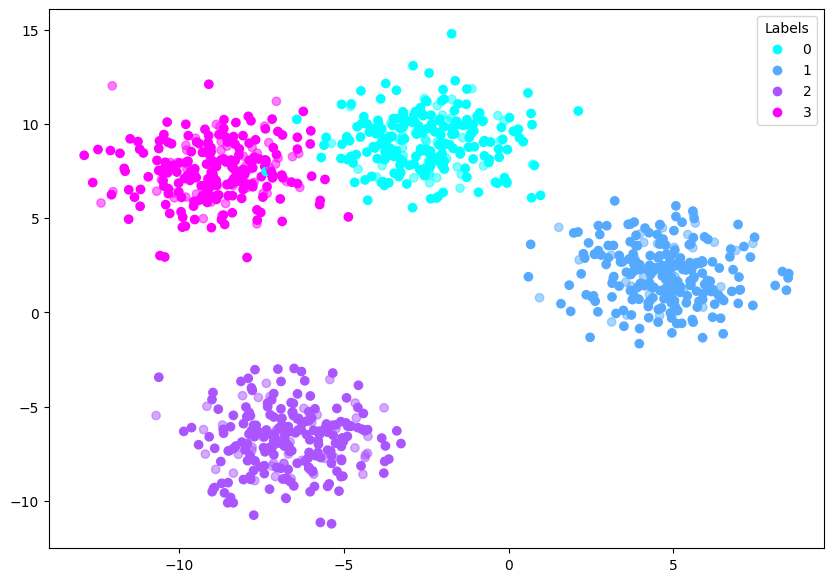

In [34]:
X_blob,y_blob=make_blobs(n_samples=1000,
                         n_features=NUM_FEATURES,
                         centers=NUM_CLASSES,
                         random_state=RANDOM_SEED,
                         cluster_std=1.5
                         )
X_blob=torch.from_numpy(X_blob).type(torch.float)
y_blob=torch.from_numpy(y_blob).type(torch.float)
X_blob_train,X_blob_test,y_blob_train,y_blob_test=train_test_split(X_blob,y_blob,test_size=0.2,random_state=RANDOM_SEED)

plt.figure(figsize=(10,7))
scatter=plt.scatter(X_blob_train[:,0],X_blob_train[:,1],c=y_blob_train,cmap=plt.cm.cool)
plt.legend(*scatter.legend_elements(), title="Labels")
plt.scatter(X_blob_test[:,0],X_blob_test[:,1],c=y_blob_test,cmap=plt.cm.cool,alpha=0.5)

In [35]:
# creating device agnostic code
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [36]:
torch.unique(y_blob_train)

tensor([0., 1., 2., 3.])

In [37]:
# Building the model

class BlobModel(nn.Module):
  def __init__(self,inputFeatures,outFeatures,hiddenUnits=8):
    super().__init__()
    self.layer1=nn.Linear(in_features=inputFeatures,out_features=hiddenUnits*2)
    self.relu=nn.ReLU()
    self.layer2=nn.Linear(in_features=hiddenUnits*2,out_features=hiddenUnits)
    self.layer3=nn.Linear(in_features=hiddenUnits,out_features=outFeatures)
  def forward(self,x):
    return self.layer3(self.relu(self.layer2(self.relu(self.layer1(x)))))


In [38]:
modelMulti=BlobModel(2,4,8).to(device)

In [39]:
lossMulti=nn.CrossEntropyLoss()
optimizerMulti=torch.optim.Adam(params=modelMulti.parameters(),lr=0.01)

In [40]:
modelMulti.eval()
with torch.inference_mode():
  yPred=modelMulti(X_blob_test.to(device))
print(yPred)
yVal=torch.softmax(yPred,dim=1)
torch.sum(yVal[0])

# sum of each row will be 1


tensor([[ 3.0995e-01,  4.9435e-01, -7.6088e-01,  1.4232e-01],
        [-4.0111e-03, -1.6498e-02, -4.4748e-02, -1.8394e-01],
        [ 8.5365e-02,  6.4646e-02, -2.3154e-01, -2.0671e-01],
        [ 2.9283e-01,  4.3665e-01, -3.9511e-01,  1.8011e-01],
        [ 5.6331e-02, -8.1016e-02, -1.8678e-01, -2.4732e-01],
        [-1.6434e-02,  4.0867e-04, -8.7774e-02, -1.9503e-01],
        [ 1.3724e-02,  7.3397e-02, -1.9944e-01, -1.6165e-01],
        [ 7.8994e-02, -1.0710e-01, -1.0679e-02, -2.9121e-01],
        [ 1.6111e-01,  1.0885e-01, -2.1190e-01, -1.3503e-01],
        [ 7.6126e-02, -1.0276e-01, -5.6492e-02, -2.9212e-01],
        [ 6.2358e-02, -9.2671e-02,  2.4723e-02, -2.3948e-01],
        [ 3.7994e-01,  6.6724e-01, -9.1020e-01,  2.8679e-01],
        [ 6.5557e-02, -9.0713e-02, -1.3595e-01, -2.7092e-01],
        [ 8.4397e-02, -1.1012e-01, -4.1131e-02, -3.2158e-01],
        [ 7.8049e-02, -1.0282e-01, -9.0294e-02, -3.0925e-01],
        [ 1.0869e-02, -3.4789e-02, -1.5430e-02, -1.8655e-01],
        

tensor(1.)

In [41]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
# Training the model
epochs=1000
X_blob_train,y_blob_train=X_blob_train.to(device),y_blob_train.to(device)
X_blob_test,y_blob_test=X_blob_test.to(device),y_blob_test.to(device)

for epoch in range(epochs):
  modelMulti.train()
  yLogits=modelMulti(X_blob_train)
  yPred=torch.softmax(yLogits,dim=1).argmax(dim=1)
  loss=lossMulti(yLogits,y_blob_train.long())
  acc=accuracy_fn(y_blob_train,yPred)
  optimizerMulti.zero_grad()
  loss.backward()
  optimizerMulti.step()

  modelMulti.eval()
  with torch.inference_mode():
    yTestLogits=modelMulti(X_blob_test)
    yTestPred=torch.softmax(yTestLogits,dim=1).argmax(dim=1)
    testLoss=lossMulti(yTestLogits,y_blob_test.long())
    accTest=accuracy_fn(y_blob_test,yTestPred)
    if epoch%100==0:
      print(f"Epoch:{epoch} | loss {loss:.5f}|accuracy {acc:.5f} | test loss {testLoss:.5f} | test accuracy {accTest: .2f}")





Epoch:0 | loss 1.33477|accuracy 49.25000 | test loss 1.27118 | test accuracy  60.50
Epoch:100 | loss 0.02389|accuracy 99.25000 | test loss 0.01215 | test accuracy  99.50
Epoch:200 | loss 0.02046|accuracy 99.50000 | test loss 0.00892 | test accuracy  99.50
Epoch:300 | loss 0.01827|accuracy 99.50000 | test loss 0.00674 | test accuracy  100.00
Epoch:400 | loss 0.01660|accuracy 99.37500 | test loss 0.00506 | test accuracy  100.00
Epoch:500 | loss 0.01552|accuracy 99.37500 | test loss 0.00397 | test accuracy  100.00
Epoch:600 | loss 0.01482|accuracy 99.37500 | test loss 0.00333 | test accuracy  100.00
Epoch:700 | loss 0.01437|accuracy 99.37500 | test loss 0.00294 | test accuracy  100.00
Epoch:800 | loss 0.01409|accuracy 99.37500 | test loss 0.00267 | test accuracy  100.00
Epoch:900 | loss 0.01394|accuracy 99.37500 | test loss 0.00249 | test accuracy  100.00


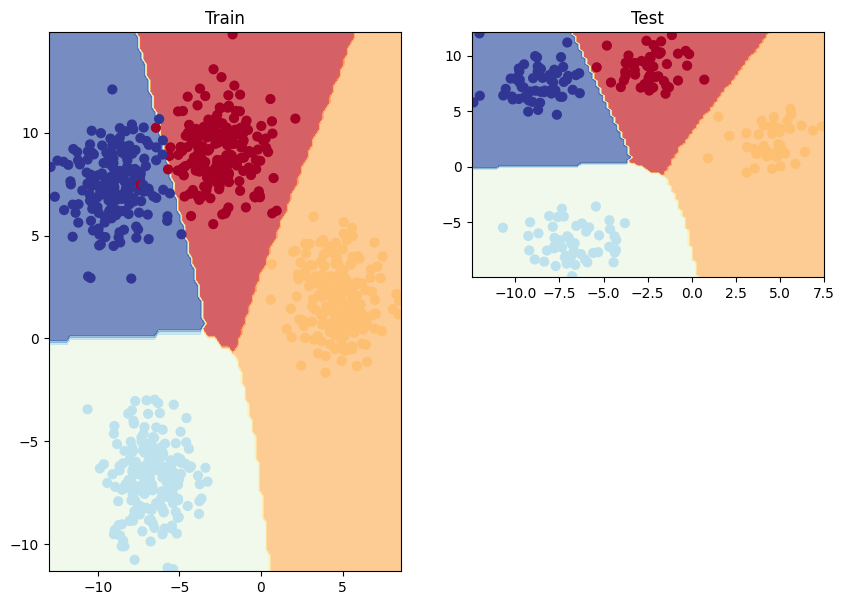

In [42]:
plt.figure(figsize=(10,7))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(modelMulti,X_blob_train,y_blob_train)
plt.subplot(2,2,2)
plt.title("Test")
plot_decision_boundary(modelMulti,X_blob_test,y_blob_test)

In [46]:
from sklearn.metrics import precision_score,recall_score,f1_score,classification_report

In [48]:

print(classification_report(y_blob_test, yTestPred))


              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        49
         1.0       1.00      1.00      1.00        41
         2.0       1.00      1.00      1.00        53
         3.0       1.00      1.00      1.00        57

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [49]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


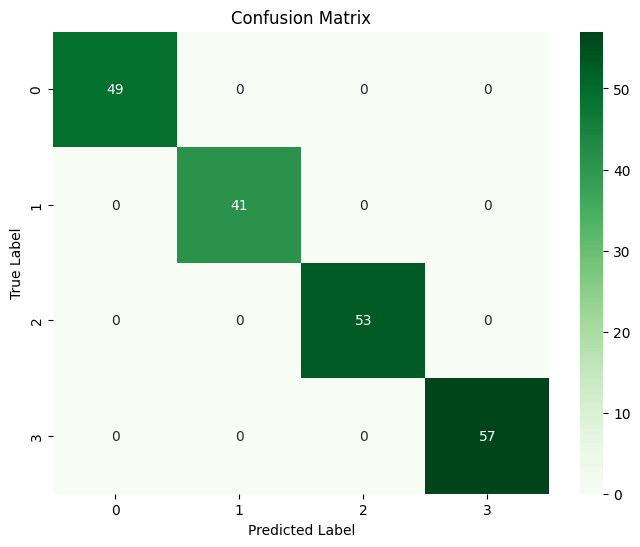

In [51]:
labels = ['0','1', '2', '3']
cm = confusion_matrix(y_blob_test, yTestPred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()
